# Web Scraping for OSINT and Threat Intelligence

In this laboratory, we will explore the fundamentals of web scraping and its applications in Open Source Intelligence (OSINT). We will cover two primary techniques:

1. **Static Analysis with BeautifulSoup**: Parsing raw HTML source code to extract data, including non-rendered parts like metadata.
2. **Dynamic Execution with Playwright**: Automating a real browser to execute JavaScript and interact with modern, dynamic web applications.

---

## 1. Environment Setup
First, we need to ensure all required libraries are installed. 

In [1]:
# !pip install beautifulsoup4 requests pandas matplotlib seaborn playwright nest_asyncio
# !playwright install chromium

## 2. Example 1: Static Scraping with BeautifulSoup
BeautifulSoup is used to parse the **raw HTML** returned by a server. It is fast and allows us to see "under the hood" at elements that might not be visible in the final rendered page.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "http://quotes.toscrape.com"
print(f"[*] Fetching {url}...")

try:
    response = requests.get(url)
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, "html.parser")
        
        quotes = soup.find_all("div", class_="quote")
        
        quotes_list = []
        for q in quotes:
            text = q.find("span", class_="text").get_text()
            author = q.find("small", class_="author").get_text()
            
            quotes_list.append({
                "Quote": text,
                "Author": author
            })
        
        df = pd.DataFrame(quotes_list)
        print("\n[+] Scraped Data Sample bits:")
        print(df.head())
    else:
        print(f"[-] Error: {response.status_code}")
except Exception as e:
    print(f"[-] Connection Error: {e}")

[*] Fetching http://quotes.toscrape.com...

[+] Scraped Data Sample bits:
                                               Quote           Author
0  “The world as we have created it is a process ...  Albert Einstein
1  “It is our choices, Harry, that show what we t...     J.K. Rowling
2  “There are only two ways to live your life. On...  Albert Einstein
3  “The person, be it gentleman or lady, who has ...      Jane Austen
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe


## 3. Example 2: Inspecting Hidden Metadata (OSINT Focus)
Unlike a browser, which only shows what is "rendered," BeautifulSoup can find hidden data, metadata, or comments.

In [3]:
print("--- Metadata Found ---")
target_url = "https://www.google.com"
res = requests.get(target_url)
soup_meta = BeautifulSoup(res.text, "html.parser")

for tag in soup_meta.find_all("meta"):
    print(f"Meta Tag: {tag.attrs}")

print("\n--- Script Sources ---")
for script in soup_meta.find_all("script", src=True):
    print(f"Found Script: {script['src']}")

--- Metadata Found ---
Meta Tag: {'content': 'text/html; charset=UTF-8', 'http-equiv': 'Content-Type'}
Meta Tag: {'content': '/images/branding/googleg/1x/googleg_standard_color_128dp.png', 'itemprop': 'image'}

--- Script Sources ---


## 4. Example 3: Dynamic Scraping with Playwright (Async version for Jupyter)
In Jupyter Notebooks, Playwright must be used in **Async** mode because the notebook itself runs inside an event loop.

In [ ]:
import asyncio
from playwright.async_api import async_playwright

async def run_dynamic_scrape():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        print("[*] Navigating to JS-rendered page...")
        await page.goto("http://quotes.toscrape.com/js/")
        
        await page.wait_for_selector(".quote")
        
        first_quote = await page.inner_text(".quote .text")
        print(f"\n[+] Found dynamic quote: {first_quote}")
        
        await browser.close()

await run_dynamic_scrape()

[*] Navigating to JS-rendered page...

[+] Found dynamic quote: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”


## 5. Example 4: Advanced Playwright - Pagination and Aggregation
In this exercise, we will use Playwright to navigate through multiple pages of a JS-rendered site.

In [ ]:
async def scrape_multiple_pages(max_pages=2):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        url = "http://quotes.toscrape.com/js/"
        print(f"[*] Starting multi-page scrape at {url}")
        await page.goto(url)
        
        all_quotes = []
        current_page = 1
        
        while current_page <= max_pages:
            print(f"[*] Scraping Page {current_page}...")
            await page.wait_for_selector(".quote")
            
            quotes = await page.locator(".quote").all()
            for q in quotes:
                text = await q.locator(".text").inner_text()
                author = await q.locator(".author").inner_text()
                all_quotes.append({"Quote": text, "Author": author})
            
            next_button = page.locator(".next a")
            if await next_button.count() > 0:
                await next_button.click()
                current_page += 1
                await asyncio.sleep(1)
            else:
                break
        
        await browser.close()
        return pd.DataFrame(all_quotes)

multi_df = await scrape_multiple_pages(max_pages=2)
print(multi_df.head())

[*] Starting multi-page scrape at http://quotes.toscrape.com/js/
[*] Scraping Page 1...
[*] Scraping Page 2...
                                               Quote           Author
0  “The world as we have created it is a process ...  Albert Einstein
1  “It is our choices, Harry, that show what we t...     J.K. Rowling
2  “There are only two ways to live your life. On...  Albert Einstein
3  “The person, be it gentleman or lady, who has ...      Jane Austen
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe


/tmp/ipykernel_93003/258875631.py:31: RuntimeWarning: coroutine 'Browser.close' was never awaited
  browser.close()


## 6. Example 5: Comprehensive Scrape & Visual Analytics
In this longer exercise, we will scrape multiple pages of an e-commerce catalog (**Books to Scrape**) to extract numerical and categorical data.

In [ ]:
import re

def scrape_books(pages=3):
    base_url = "http://books.toscrape.com/catalogue/page-{}.html"
    books_list = []
    
    rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
    
    print(f"[*] Scraping {pages} pages of book data...")
    for p in range(1, pages + 1):
        url = base_url.format(p)
        res = requests.get(url)
        res.encoding = res.apparent_encoding
        
        soup = BeautifulSoup(res.text, "html.parser")
        
        articles = soup.find_all("article", class_="product_pod")
        for art in articles:
            title = art.h3.a["title"]
            price_text = art.find("p", class_="price_color").get_text()
            
            price_clean = re.sub(r'[^\d.]', '', price_text)
            
            rating_classes = art.find("p", class_="star-rating")["class"]
            rating_text = [c for c in rating_classes if c != "star-rating"][0]
            
            books_list.append({
                "Title": title,
                "Price": float(price_clean),
                "Rating": rating_map.get(rating_text, 0)
            })
            
    return pd.DataFrame(books_list)

df_full = scrape_books(pages=5)
print(f"\n[+] Scraped {len(df_full)} items.")
display(df_full.head())

[*] Scraping 5 pages of book data...

[+] Scraped 100 items.


,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


### Generating the Intelligence Report
Now we use the scraped data to generate a multi-plot visualization showing the distribution of ratings and prices.

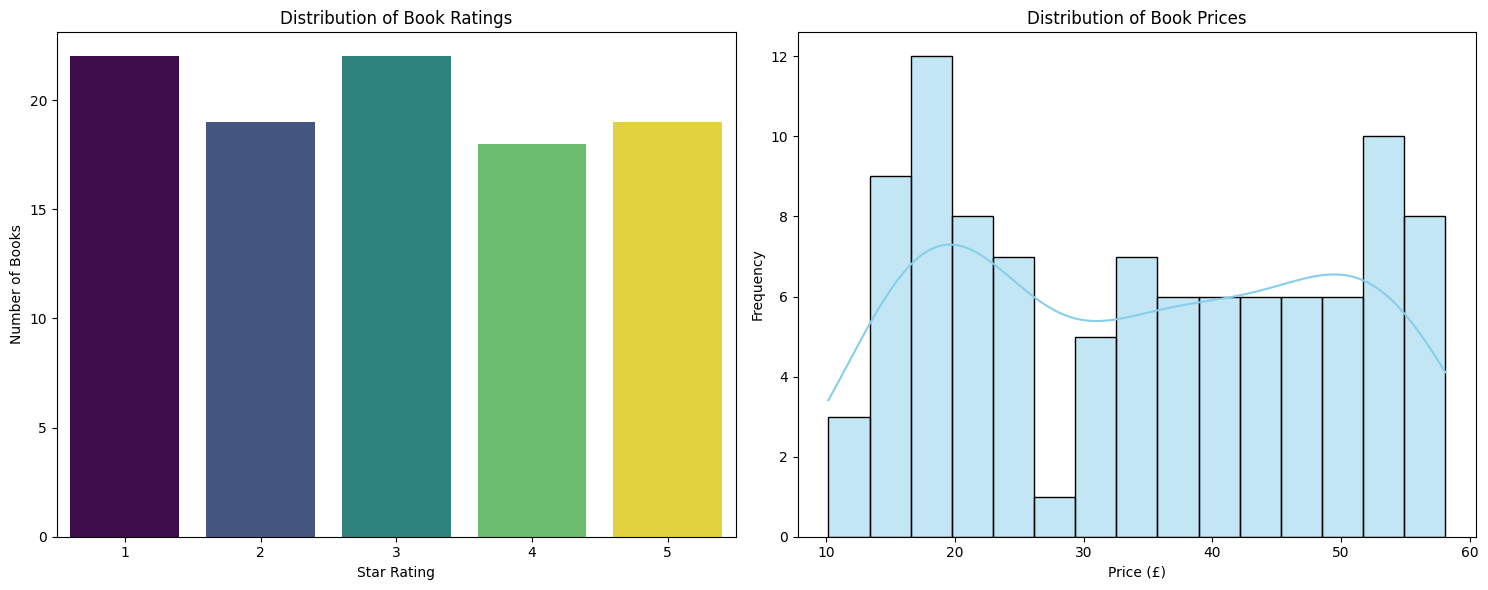

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_full' in locals() and not df_full.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    sns.countplot(data=df_full, x="Rating", hue="Rating", palette="viridis", legend=False, ax=ax1)
    ax1.set_title("Distribution of Book Ratings")
    ax1.set_xlabel("Star Rating")
    ax1.set_ylabel("Number of Books")

    sns.histplot(data=df_full, x="Price", bins=15, kde=True, color="skyblue", ax=ax2)
    ax2.set_title("Distribution of Book Prices")
    ax2.set_xlabel("Price (£)")
    ax2.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()
else:
    print("[-] No data found to plot. Run Example 5 first.")